In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('online_shoppers_intention.csv')

In [2]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


# Task1.1

In [5]:
story_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

story_table = (
    df.groupby("Revenue")[story_features]
      .mean()
      .T
)

story_table.columns = ["No purchase", "Purchase"]

story_table

,No purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518


# Task1.2

In [6]:
df["BrowserGroup"] = np.where(
    df["Browser"] == 13,
    "Browser 13",
    "Other browsers"
)

print(df["BrowserGroup"].value_counts())

BrowserGroup
Other browsers    12269
Browser 13           61
Name: count, dtype: int64


In [7]:
story_table = (
    df.groupby("BrowserGroup")
      .mean(numeric_only=True)
      .T
)

story_table.columns = ["Other Browsers", "Browser 13"]

story_table

,Other Browsers,Browser 13
Administrative,1.754098,2.317956
Administrative_Duration,73.716530,80.853921
Informational,0.229508,0.504931
Informational_Duration,4.717486,34.620336
ProductRelated,14.885246,31.815225
ProductRelated_Duration,699.388395,1197.209080
BounceRates,0.034373,0.022131
ExitRates,0.052842,0.043024
PageValues,26.268249,5.787936
SpecialDay,0.000000,0.061733


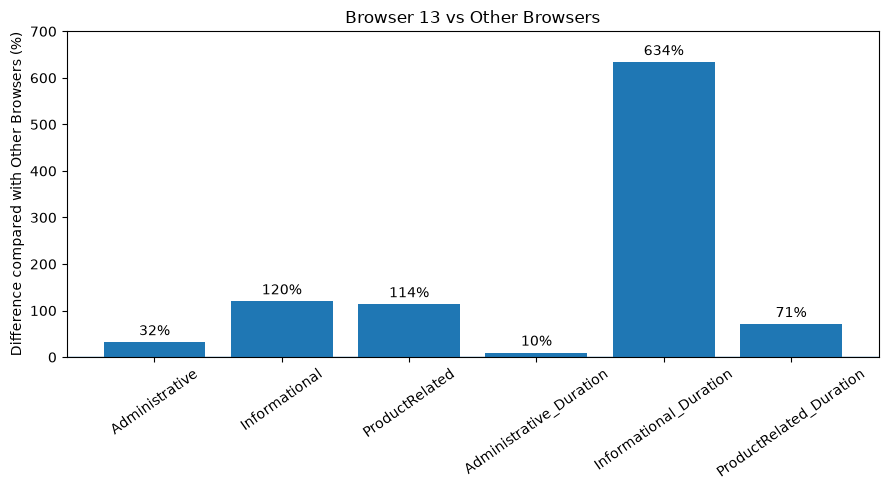

In [8]:
import matplotlib.pyplot as plt
import numpy as np

features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration"
]

other = story_table.loc[features, "Other Browsers"]
browser13 = story_table.loc[features, "Browser 13"]

# Percentage difference compared with Other Browsers
percentage_difference = ((browser13 - other) / other) * 100

# Create chart
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    features,
    percentage_difference
)

ax.axhline(0, linewidth=1)

ax.set_ylabel("Difference compared with Other Browsers (%)")
ax.set_title("Browser 13 vs Other Browsers")
ax.tick_params(axis="x", rotation=35)

# Add values above/below bars
for bar, value in zip(bars, percentage_difference):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + (15 if value >= 0 else -35),
        f"{value:.0f}%",
        ha="center"
    )

ax.set_ylim(0, 700)

plt.tight_layout()
plt.show()

# Task 2

In [11]:
# Preprocessing
# Standardization/normalization
df_scaled = df.copy()

from sklearn.preprocessing import StandardScaler

# Include numeric values
numeric_cols = df_scaled.select_dtypes(include="number").columns

# Exclude nominal variables
numeric_cols = numeric_cols.drop([
    "TrafficType",
    "Browser",
    "Region",
    "OperatingSystems"
])

# Build model
scaler = StandardScaler()

# Transform 
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

# Encode true/false into 0/1 features
df_scaled["Weekend"] = df["Weekend"].astype(int)
df_scaled["Revenue"] = df["Revenue"].astype(int)

# Encode Month
df_scaled["Month"] = df["Month"].map({
    "Jan": 1,
    "Feb": 2,
    "Mar": 3,
    "Apr": 4,
    "May": 5,
    "June": 6,
    "Jul": 7,
    "Aug": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dec": 12
})

# Encode VisitorType
df_scaled["VisitorType"] = df["VisitorType"].map({
    "New_Visitor": 0,
    "Returning_Visitor": 1,
    "Other": 2
})

# Drop BrowserGroup column
df_scaled = df_scaled.drop("BrowserGroup", axis=1)

# Display top 5 results
df_scaled.head()

# Display all results
display(df_scaled)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,2,1,1,1,1,1,0,0
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,2,2,2,1,2,1,0,0
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,2,4,1,9,3,1,0,0
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,2,3,2,2,4,1,0,0
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,2,3,3,1,4,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,0.206173,0.363075,-0.396478,-0.244931,0.478227,0.307822,-0.310366,-0.288966,0.342125,-0.308821,12,4,6,1,1,1,1,0
12326,-0.696993,-0.457191,-0.396478,-0.244931,-0.601062,-0.380957,-0.457683,-0.447364,-0.317178,-0.308821,11,3,2,1,8,1,1,0
12327,-0.696993,-0.457191,-0.396478,-0.244931,-0.578577,-0.528063,1.261014,0.897093,-0.317178,-0.308821,11,3,2,1,13,1,1,0
12328,0.507228,-0.032916,-0.396478,-0.244931,-0.376210,-0.443536,-0.457683,-0.453140,-0.317178,-0.308821,11,2,2,3,11,1,0,0


# Task 3.1 Affinity Propagation clustering

Original number of clusters: 91
Clusters with >10 observations: 49

Cluster sizes:
2      60
3      19
5      24
6      19
7      35
8      25
10     23
11     79
14     39
15     28
17     16
20     19
21     52
22     85
24     83
25     59
29     30
32     22
33     22
35     19
38     52
41     26
44     21
45     18
46     28
47     26
48     39
50     26
53     36
54     22
55     61
56     27
57     24
62     19
63     31
64     36
67     19
68     17
70    111
72     33
73     19
74     31
75     46
76     19
77     23
79     26
83     43
84     34
90     24
Name: count, dtype: int64


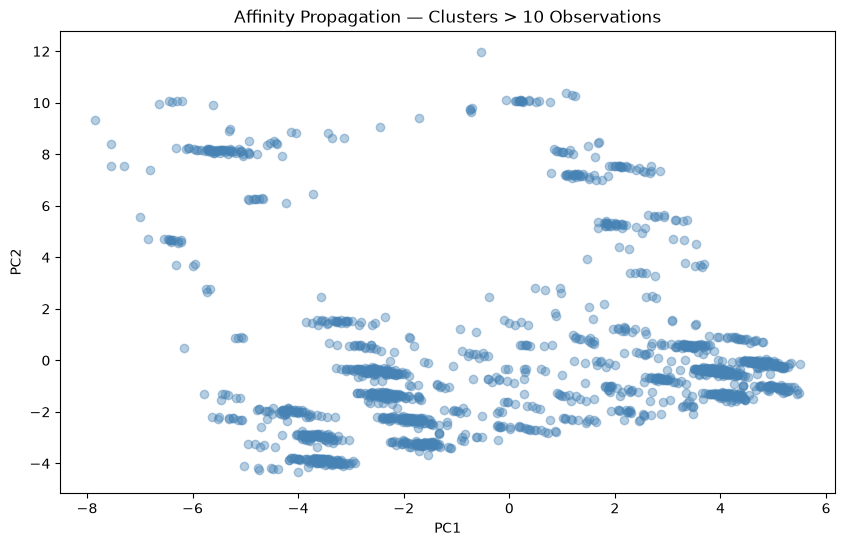

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import AffinityPropagation
from sklearn.decomposition import PCA

# Choose sample size of 2000
X = df_scaled.sample(n=min(2000, len(df_scaled)), random_state=42)

# Fit Affinity Propagation
af = AffinityPropagation(
    damping=0.9,
    max_iter=300,
    convergence_iter=15,
    random_state=42
)

labels = af.fit_predict(X)

# Count cluster sizes
cluster_sizes = pd.Series(labels).value_counts()

# Keep features that are inside of clusters with MORE than 15 observations
valid_clusters = cluster_sizes[cluster_sizes > 15].index

# Filter features
mask = pd.Series(labels, index=X.index).isin(valid_clusters)

X_filtered = X.loc[mask]
labels_filtered = labels[mask.values]

print("Original number of clusters:", len(cluster_sizes))
print("Clusters with >10 observations:", len(valid_clusters))

print("\nClusternumber and clustersizes:")
print(
    pd.Series(labels_filtered)
    .value_counts()
    .sort_index()
)

# PCA on the filtered data
X_pca = PCA(n_components=2).fit_transform(X_filtered)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.4,
    color="steelblue"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Affinity Propagation — Clusters > 15 Observations")
plt.show()


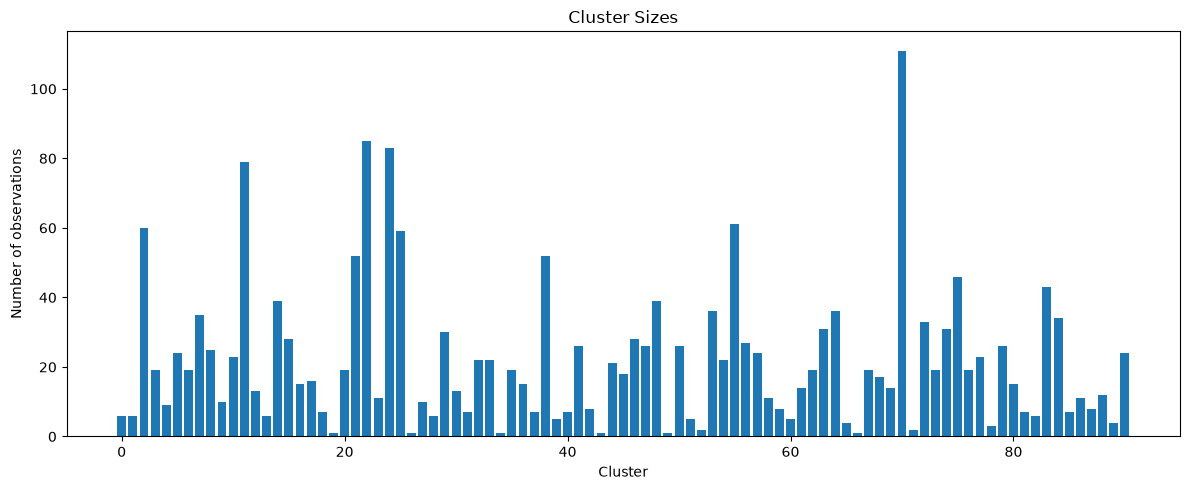

In [13]:
cluster_sizes = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(cluster_sizes.index, cluster_sizes.values)

plt.xlabel("Cluster")
plt.ylabel("Number of observations")
plt.title("Cluster Sizes")

plt.tight_layout()
plt.show()

# Task 3.2 DBSCAN clustering

In [33]:
import numpy as np
from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(df_scaled)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 0
Estimated number of noise points: 2000
